In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. Create results tables
# -----------------------------

validation_results = [
    ["Logistic Regression", "Baseline", "Full training set", 0.01, 0.3564, 0.100, 1.000, 0.181, 0.0997],
    ["Balanced Bagging Classifier", "Balanced sampling", "999,797", 0.41, 0.3807, 0.129, 0.746, 0.219, 0.1645],
    ["Balanced Random Forest", "Balanced sampling", "999,797", 0.40, 0.3808, 0.127, 0.761, 0.218, 0.1644],
    ["Random Forest", "Random undersampling", "462,580", 0.59, 0.3808, 0.127, 0.762, 0.218, 0.1615],
    ["Random Forest", "Random oversampling", "1,134,101", 0.46, 0.3782, 0.123, 0.788, 0.212, 0.1588],
    ["XGBoost", "Class weighting", "999,797", 0.21, 0.3787, 0.123, 0.794, 0.212, 0.1644],
    ["XGBoost", "Random undersampling", "462,580", 0.12, 0.3778, 0.120, 0.821, 0.209, 0.1618],
    ["XGBoost", "Random oversampling", "1,134,101", 0.12, 0.3784, 0.122, 0.802, 0.211, 0.1620],
    ["XGBoost", "Sample weighting", "999,797", 0.20, 0.3775, 0.119, 0.823, 0.208, 0.1635],
]

test_results = [
    ["Logistic Regression", "Baseline", 0.01, 0.4093, 0.122, 1.000, 0.217, 0.1217],
    ["Balanced Bagging Classifier", "Balanced sampling", 0.41, 0.4318, 0.156, 0.777, 0.259, 0.2096],
    ["Balanced Random Forest", "Balanced sampling", 0.40, 0.4327, 0.154, 0.791, 0.258, 0.2117],
    ["Random Forest", "Random undersampling", 0.59, 0.4328, 0.154, 0.788, 0.258, 0.2100],
    ["Random Forest", "Random oversampling", 0.46, 0.4324, 0.150, 0.817, 0.253, 0.2102],
    ["XGBoost", "Class weighting", 0.21, 0.4307, 0.146, 0.838, 0.249, 0.2077],
    ["XGBoost", "Random undersampling", 0.12, 0.4288, 0.143, 0.853, 0.246, 0.2096],
    ["XGBoost", "Random oversampling", 0.12, 0.4306, 0.146, 0.844, 0.248, 0.2087],
    ["XGBoost", "Sample weighting", 0.20, 0.4304, 0.144, 0.854, 0.247, 0.2124],
]

validation_df = pd.DataFrame(
    validation_results,
    columns=[
        "Model",
        "Imbalance strategy",
        "Training samples",
        "Threshold",
        "F2",
        "Precision",
        "Recall",
        "F1",
        "PR-AUC"
    ]
)

test_df = pd.DataFrame(
    test_results,
    columns=[
        "Model",
        "Imbalance strategy",
        "Threshold",
        "F2",
        "Precision",
        "Recall",
        "F1",
        "PR-AUC"
    ]
)

# Sort by F2-score, highest first
validation_df = validation_df.sort_values("F2", ascending=False).reset_index(drop=True)
test_df = test_df.sort_values("F2", ascending=False).reset_index(drop=True)

display(validation_df)
display(test_df)

,Model,Imbalance strategy,Training samples,Threshold,F2,Precision,Recall,F1,PR-AUC
0,Balanced Random Forest,Balanced sampling,"999,797",0.40,0.3808,0.127,0.761,0.218,0.1644
1,Random Forest,Random undersampling,"462,580",0.59,0.3808,0.127,0.762,0.218,0.1615
2,Balanced Bagging Classifier,Balanced sampling,"999,797",0.41,0.3807,0.129,0.746,0.219,0.1645
3,XGBoost,Class weighting,"999,797",0.21,0.3787,0.123,0.794,0.212,0.1644
4,XGBoost,Random oversampling,"1,134,101",0.12,0.3784,0.122,0.802,0.211,0.1620
5,Random Forest,Random oversampling,"1,134,101",0.46,0.3782,0.123,0.788,0.212,0.1588
6,XGBoost,Random undersampling,"462,580",0.12,0.3778,0.120,0.821,0.209,0.1618
7,XGBoost,Sample weighting,"999,797",0.20,0.3775,0.119,0.823,0.208,0.1635
8,Logistic Regression,Baseline,Full training set,0.01,0.3564,0.100,1.000,0.181,0.0997


,Model,Imbalance strategy,Threshold,F2,Precision,Recall,F1,PR-AUC
0,Random Forest,Random undersampling,0.59,0.4328,0.154,0.788,0.258,0.2100
1,Balanced Random Forest,Balanced sampling,0.40,0.4327,0.154,0.791,0.258,0.2117
2,Random Forest,Random oversampling,0.46,0.4324,0.150,0.817,0.253,0.2102
3,Balanced Bagging Classifier,Balanced sampling,0.41,0.4318,0.156,0.777,0.259,0.2096
4,XGBoost,Class weighting,0.21,0.4307,0.146,0.838,0.249,0.2077
5,XGBoost,Random oversampling,0.12,0.4306,0.146,0.844,0.248,0.2087
6,XGBoost,Sample weighting,0.20,0.4304,0.144,0.854,0.247,0.2124
7,XGBoost,Random undersampling,0.12,0.4288,0.143,0.853,0.246,0.2096
8,Logistic Regression,Baseline,0.01,0.4093,0.122,1.000,0.217,0.1217


In [3]:
def save_apa_table(
    df,
    title,
    note,
    filename,
    figsize=(13, 4.8),
    font_size=9
):
    """
    Saves a dataframe as an APA-style table image.
    APA-style features:
    - Table number/title above table
    - Minimal horizontal lines
    - No vertical gridlines
    - Note below table
    """
    
    df_display = df.copy()

    # Format numeric columns
    for col in df_display.columns:
        if col in ["Threshold", "F2", "Precision", "Recall", "F1", "PR-AUC"]:
            df_display[col] = df_display[col].map(lambda x: f"{x:.3f}")

    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("off")

    # Title
    ax.text(
        0,
        1.10,
        title,
        fontsize=12,
        fontweight="bold",
        ha="left",
        va="bottom",
        transform=ax.transAxes
    )

    # Table
    table = ax.table(
        cellText=df_display.values,
        colLabels=df_display.columns,
        cellLoc="center",
        colLoc="center",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(font_size)
    table.scale(1, 1.4)

    # APA-like styling
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("white")
        cell.set_linewidth(0)

        if row == 0:
            cell.set_text_props(weight="bold")
            cell.set_facecolor("white")
        else:
            cell.set_facecolor("white")

    # Add horizontal lines manually
    ax.plot([0, 1], [0.93, 0.93], color="black", linewidth=1.2, transform=ax.transAxes)
    ax.plot([0, 1], [0.86, 0.86], color="black", linewidth=0.8, transform=ax.transAxes)
    ax.plot([0, 1], [0.13, 0.13], color="black", linewidth=1.2, transform=ax.transAxes)

    # Note
    ax.text(
        0,
        -0.08,
        note,
        fontsize=9,
        ha="left",
        va="top",
        wrap=True,
        transform=ax.transAxes
    )

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

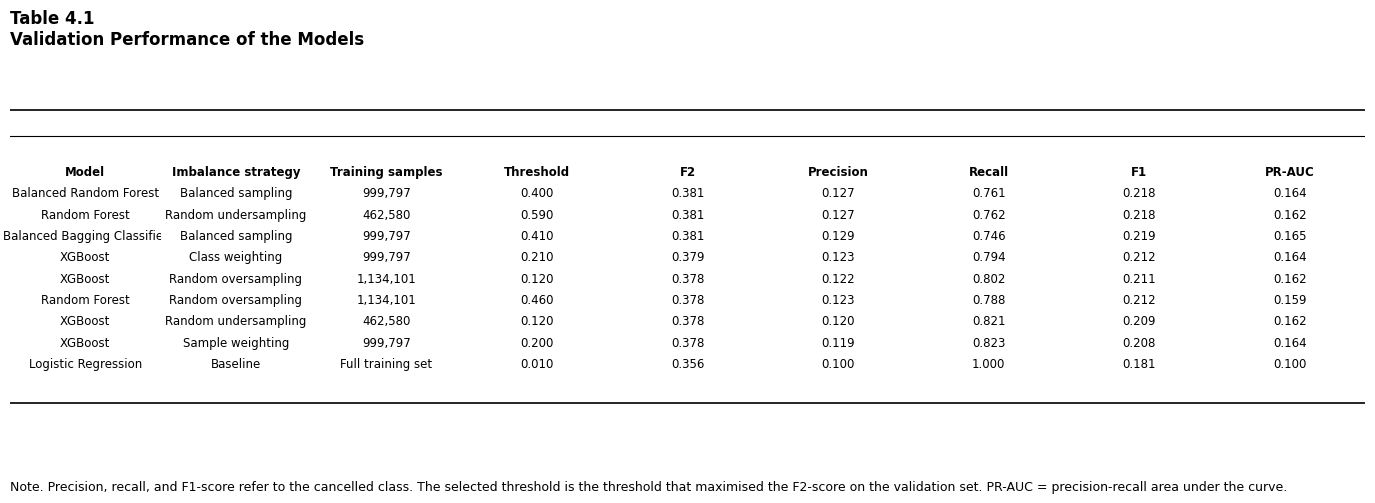

In [4]:
save_apa_table(
    validation_df,
    title="Table 4.1\nValidation Performance of the Models",
    note=(
        "Note. Precision, recall, and F1-score refer to the cancelled class. "
        "The selected threshold is the threshold that maximised the F2-score on the validation set. "
        "PR-AUC = precision-recall area under the curve."
    ),
    filename="table_4_1_validation_performance.png",
    figsize=(15, 5.2),
    font_size=8.5
)

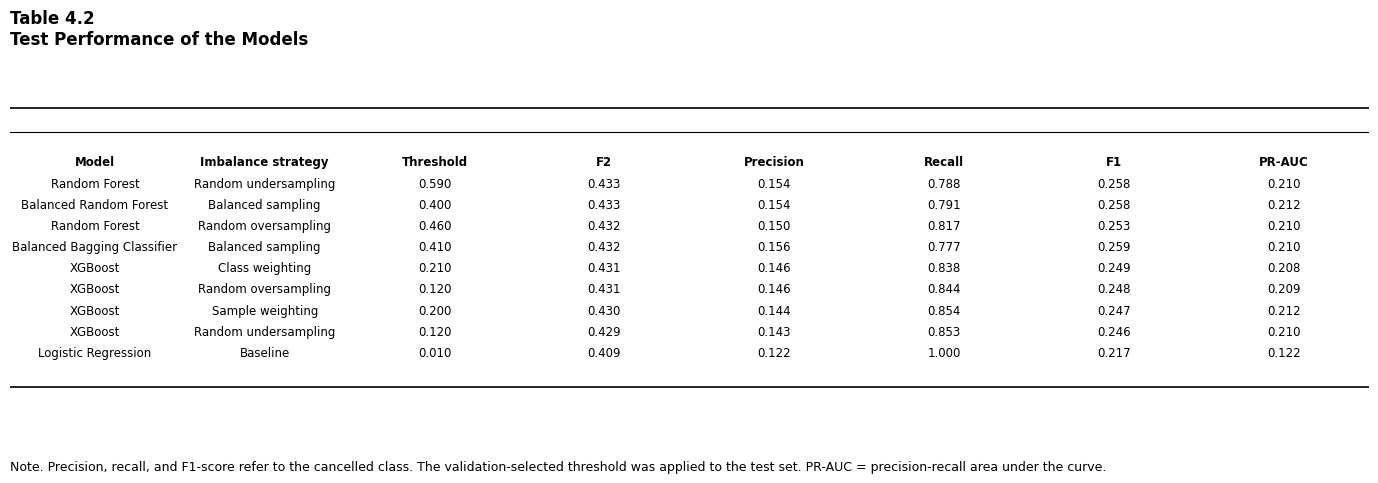

In [5]:
save_apa_table(
    test_df,
    title="Table 4.2\nTest Performance of the Models",
    note=(
        "Note. Precision, recall, and F1-score refer to the cancelled class. "
        "The validation-selected threshold was applied to the test set. "
        "PR-AUC = precision-recall area under the curve."
    ),
    filename="table_4_2_test_performance.png",
    figsize=(14, 5.0),
    font_size=8.5
)

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Best hyperparameter table
# -----------------------------

hyperparams = [
    # XGBoost
    ["XGBoost", "n_estimators", "200"],
    ["XGBoost", "max_depth", "10"],
    ["XGBoost", "learning_rate", "0.05"],
    ["XGBoost", "subsample", "0.60"],
    ["XGBoost", "colsample_bytree", "1.00"],
    ["XGBoost", "min_child_weight", "50"],
    ["XGBoost", "gamma", "2"],
    ["XGBoost", "reg_alpha", "0.10"],
    ["XGBoost", "reg_lambda", "5"],
    ["XGBoost", "scale_pos_weight", "5.00"],

    # Balanced Random Forest
    ["Balanced Random Forest", "n_estimators", "500"],
    ["Balanced Random Forest", "max_depth", "None"],
    ["Balanced Random Forest", "min_samples_split", "50"],
    ["Balanced Random Forest", "min_samples_leaf", "20"],
    ["Balanced Random Forest", "max_features", "sqrt"],
    ["Balanced Random Forest", "sampling_strategy", "auto"],
    ["Balanced Random Forest", "replacement", "True"],
    ["Balanced Random Forest", "criterion", "gini"],

    # Balanced Bagging Classifier
    ["Balanced Bagging Classifier", "n_estimators", "500"],
    ["Balanced Bagging Classifier", "base_estimator", "Decision Tree"],
    ["Balanced Bagging Classifier", "max_depth", "None"],
    ["Balanced Bagging Classifier", "min_samples_split", "20"],
    ["Balanced Bagging Classifier", "min_samples_leaf", "50"],
    ["Balanced Bagging Classifier", "max_features", "sqrt"],
    ["Balanced Bagging Classifier", "criterion", "gini"],
    ["Balanced Bagging Classifier", "sampling_strategy", "auto"],
    ["Balanced Bagging Classifier", "replacement", "True"],
    ["Balanced Bagging Classifier", "bootstrap", "True"],
]

hyperparams_df = pd.DataFrame(
    hyperparams,
    columns=["Model", "Hyperparameter", "Selected value"]
)

display(hyperparams_df)

,Model,Hyperparameter,Selected value
0,XGBoost,n_estimators,200
1,XGBoost,max_depth,10
2,XGBoost,learning_rate,0.05
3,XGBoost,subsample,0.60
4,XGBoost,colsample_bytree,1.00
5,XGBoost,min_child_weight,50
6,XGBoost,gamma,2
7,XGBoost,reg_alpha,0.10
8,XGBoost,reg_lambda,5
9,XGBoost,scale_pos_weight,5.00


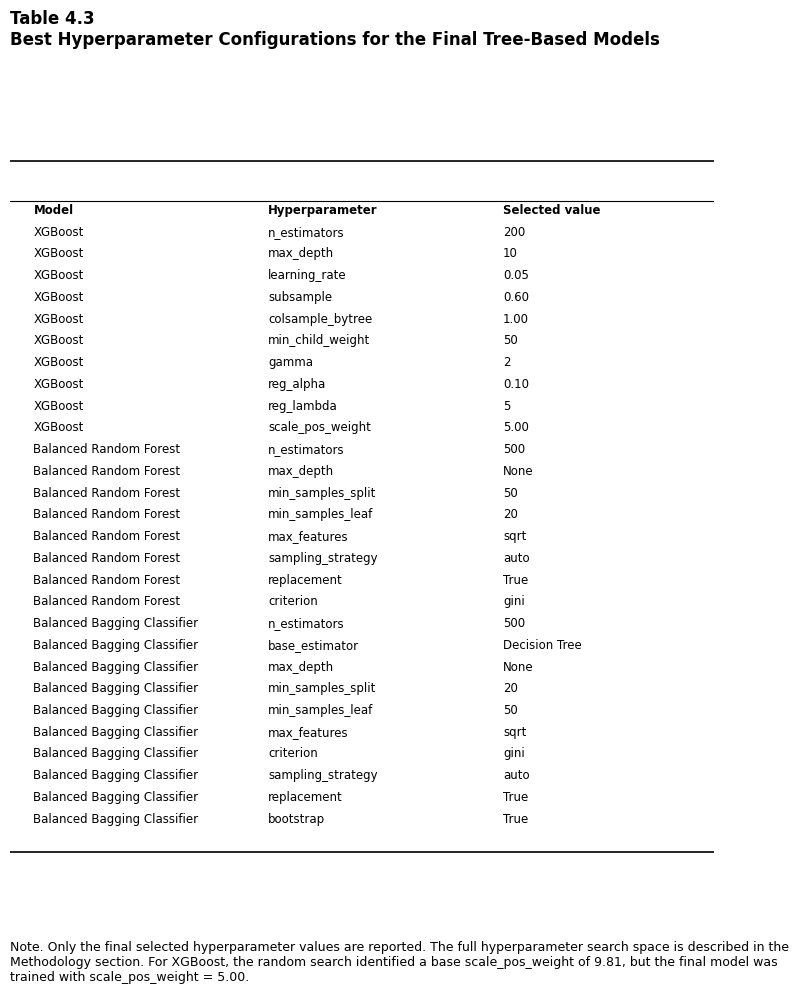

In [13]:
def save_apa_table(
    df,
    title,
    note,
    filename,
    figsize=(10, 8),
    font_size=9
):
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("off")

    ax.text(
        0,
        1.08,
        title,
        fontsize=12,
        fontweight="bold",
        ha="left",
        va="bottom",
        transform=ax.transAxes
    )

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="left",
        colLoc="left",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(font_size)
    table.scale(1, 1.25)

    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("white")
        cell.set_linewidth(0)

        if row == 0:
            cell.set_text_props(weight="bold")
            cell.set_facecolor("white")
        else:
            cell.set_facecolor("white")

    # APA-style horizontal rules
    ax.plot([0, 1], [0.94, 0.94], color="black", linewidth=1.2, transform=ax.transAxes)
    ax.plot([0, 1], [0.89, 0.89], color="black", linewidth=0.8, transform=ax.transAxes)
    ax.plot([0, 1], [0.08, 0.08], color="black", linewidth=1.2, transform=ax.transAxes)

    ax.text(
        0,
        -0.03,
        note,
        fontsize=9,
        ha="left",
        va="top",
        wrap=True,
        transform=ax.transAxes
    )

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


save_apa_table(
    hyperparams_df,
    title="Table 4.3\nBest Hyperparameter Configurations for the Final Tree-Based Models",
    note=(
        "Note. Only the final selected hyperparameter values are reported. "
        "The full hyperparameter search space is described in the Methodology section. "
        "For XGBoost, the random search identified a base scale_pos_weight of 9.81, "
        "but the final model was trained with scale_pos_weight = 5.00."
    ),
    filename="table_4_3_best_hyperparameters.png",
    figsize=(8, 10),
    font_size=8.5
)